# 00_01 — Validación de `FunctionalRepresentation`

Notebook dedicado a validar la clase de representación funcional refactorizada para PSBP-FD v1.

**Clase bajo prueba:** `model_psbp_fd.functions_models.FunctionalRepresentation`

**Métodos soportados a validar:**
- `bspline` (proyección sobre B-splines)
- `fourier` (proyección sobre Fourier)
- `fpca` (Functional PCA directo)
- `bspline+fpca` (encadenado: B-spline → FPCA sobre coeficientes)
- `fourier+fpca` (encadenado: Fourier → FPCA sobre coeficientes)

**Parámetros nuevos a validar:**
- `projection ∈ {'l2', 'discrete'}` — métrica de proyección sobre la base.
- `quadrature ∈ {'trapezoid', 'simpson'}` — regla de cuadratura para integrales L².
- `n_basis_fpca` — número de componentes FPCA finales (solo aplica a métodos con FPCA).
- `center: bool` — centrado opcional de las curvas antes de proyectar.

**Modo alternativo:** `from_coefficients` (instancia frozen sin base subyacente).

---

**Estructura del notebook**

| Sección | Contenido |
|---------|-----------|
| 1 | Setup, imports, configuración |
| 2 | Simulación de curvas con 3 modos latentes |
| 3 | Validación básica: shapes y propiedades por método |
| 4 | Proyección L² vs discreta |
| 5 | Cuadratura trapezoidal vs Simpson |
| 6 | Encadenado base→FPCA — comparación con FPCA puro |
| 7 | Centrado: efecto sobre coeficientes y reconstrucción |
| 8 | `from_coefficients` — instancias frozen |
| 9 | Comparación global: método × K → RMSE L² |
| 10 | `report()` — mini-reporte de diagnóstico |
| 11 | Manejo de errores |
| 12 | Resumen final |
| -- | *Pendiente: integración con `FunctionalStandarizer` (futura clase)* |

## 1. Setup e imports

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cargar dependencias y configurar entorno.
#   - skfda es requerido para todos los métodos excepto from_coefficients.
#   - RNG con semilla fija para reproducibilidad exacta de los datos sintéticos.
#   - rcParams aplica estilo visual uniforme.
# ═══════════════════════════════════════════════════════════════════════════
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Localizar raíz del proyecto ──────────────────────────────────────────
def get_project_root(marker="README.md"):
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current

PROJECT_ROOT = get_project_root("README.md")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Importar la clase ────────────────────────────────────────────────────
from model_psbp_fd.functions_models import FunctionalRepresentation

# ── Verificar skfda ──────────────────────────────────────────────────────
try:
    import skfda
    SKFDA_AVAILABLE = True
    print(f"skfda disponible: v{skfda.__version__}")
except ImportError:
    SKFDA_AVAILABLE = False
    print("skfda NO disponible — instalar con: pip install scikit-fda")

RNG = np.random.default_rng(42)

plt.rcParams.update({
    "figure.dpi":        110,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.size":         9,
})

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FunctionalRepresentation: {FunctionalRepresentation}")

skfda disponible: v0.10.1
PROJECT_ROOT: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
FunctionalRepresentation: <class 'model_psbp_fd.functions_models.functions_repre_functional.FunctionalRepresentation'>


## 2. Simulación de curvas funcionales

Generamos **T = 80 curvas** evaluadas en **G = 301 puntos** del intervalo $[0, 2\pi]$.
Usamos G impar para permitir Simpson sin caer a trapezoidal.

Cada curva sigue el modelo:
$$y_t(s) = a_t \sin(s) + b_t \cos(2s) + c_t \sin(3s) + \varepsilon_t(s)$$

Tres modos latentes con varianzas decrecientes — ideal para que FPCA recupere exactamente K=3 componentes.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Datos sintéticos con 3 modos latentes conocidos.
# Importante: G impar permite Simpson sin warning.
# ═══════════════════════════════════════════════════════════════════════════
T = 80
G = 301
domain = (0.0, 2 * np.pi)
grid   = np.linspace(domain[0], domain[1], G)

# Coeficientes aleatorios — varianzas decrecientes → 3 modos jerarquizados
a = RNG.normal(0, 1.2, size=T)    # modo 1: sin(s)
b = RNG.normal(0, 0.8, size=T)    # modo 2: cos(2s)
c = RNG.normal(0, 0.5, size=T)    # modo 3: sin(3s)

noise_std = 0.05

Y = (
    a[:, None] * np.sin(grid)
  + b[:, None] * np.cos(2 * grid)
  + c[:, None] * np.sin(3 * grid)
  + RNG.normal(0, noise_std, size=(T, G))
)

print(f"Y shape           : {Y.shape}")
print(f"grid              : G={G} puntos en {domain}")
print(f"varianzas modos   : sin(s)={a.var():.3f}, cos(2s)={b.var():.3f}, sin(3s)={c.var():.3f}")
print(f"varianza esperada FPC1: ~{a.var()/(a.var()+b.var()+c.var())*100:.1f}%")

Y shape           : (80, 301)
grid              : G=301 puntos en (0.0, 6.283185307179586)
varianzas modos   : sin(s)=0.853, cos(2s)=0.562, sin(3s)=0.234
varianza esperada FPC1: ~51.7%


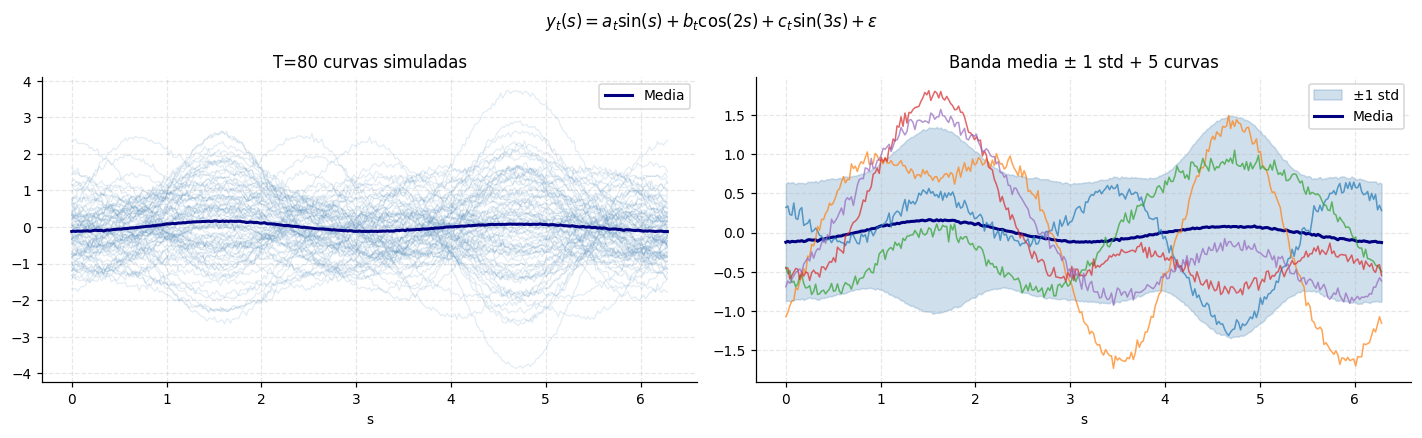

In [4]:
# ── Inspección visual de los datos ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for i in range(T):
    ax.plot(grid, Y[i], color="steelblue", alpha=0.15, lw=0.8)
ax.plot(grid, Y.mean(0), color="navy", lw=2, label="Media")
ax.set_title(f"T={T} curvas simuladas")
ax.set_xlabel("s")
ax.legend()

ax = axes[1]
mu  = Y.mean(0); std = Y.std(0)
ax.fill_between(grid, mu - std, mu + std, alpha=0.25, color="steelblue", label="±1 std")
ax.plot(grid, mu, color="navy", lw=2, label="Media")
for i in range(0, T, T // 5):
    ax.plot(grid, Y[i], lw=1, alpha=0.7)
ax.set_title("Banda media ± 1 std + 5 curvas")
ax.set_xlabel("s")
ax.legend()

fig.suptitle(r"$y_t(s) = a_t\sin(s) + b_t\cos(2s) + c_t\sin(3s) + \varepsilon$")
plt.tight_layout()
plt.show()

## 3. Validación básica: shapes y propiedades por método

Verificamos para cada uno de los **5 métodos** que:
- `fit_transform(Y, grid)` produce coeficientes con el shape correcto `(T, K_)`.
- `reconstruct(THETA)` produce curvas con shape `(T, G)`.
- `reconstruction_error` devuelve las **6 claves** esperadas (L² y punto a punto).
- `summary()` y `get_config()` operan tras el fit.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Verificación de la API básica de los 5 métodos.
# Cada método debe producir shapes correctos y entregar los 6 indicadores
# del reconstruction_error refactorizado.
# ═══════════════════════════════════════════════════════════════════════════
if not SKFDA_AVAILABLE:
    print("skfda no disponible — saltando validación.")
else:
    configs = [
        dict(method="bspline",      n_basis=15),
        dict(method="fourier",      n_basis=11),
        dict(method="fpca",         n_basis_fpca=3),
        dict(method="bspline+fpca", n_basis=15, n_basis_fpca=3),
        dict(method="fourier+fpca", n_basis=11, n_basis_fpca=3),
    ]

    print(f"{'método':<14} {'K_':>4} {'shape THETA':>15} {'shape Y_hat':>15}"
          f" {'RMSE L²':>10} {'RMSE pw':>10}")
    print("-" * 78)

    for cfg in configs:
        r = FunctionalRepresentation(**cfg)
        THETA = r.fit_transform(Y, grid)
        Y_hat = r.reconstruct(THETA)
        err   = r.reconstruction_error(Y, grid)

        # Verificación de claves nuevas
        expected_keys = {"rmse_l2_mean", "rmse_l2_std",
                         "rmse_pw_mean", "rmse_pw_std",
                         "rel_l2_mean", "rel_l2_std"}
        assert set(err.keys()) == expected_keys, f"Claves err inesperadas: {err.keys()}"

        print(f"{cfg['method']:<14} {r.K_:>4} {str(THETA.shape):>15} "
              f"{str(Y_hat.shape):>15} {err['rmse_l2_mean']:>10.4f} {err['rmse_pw_mean']:>10.4f}")

método           K_     shape THETA     shape Y_hat    RMSE L²    RMSE pw
------------------------------------------------------------------------------
bspline          15        (80, 15)       (80, 301)     0.1228     0.0490
fourier          11        (80, 11)       (80, 301)     0.1232     0.0492
fpca              3         (80, 3)       (80, 301)     0.1218     0.0486
bspline+fpca      3         (80, 3)       (80, 301)     0.1252     0.0500
fourier+fpca      3         (80, 3)       (80, 301)     0.1249     0.0498


In [6]:
# ── summary() y get_config() ─────────────────────────────────────────────
if SKFDA_AVAILABLE:
    r_demo = FunctionalRepresentation(method="bspline+fpca",
                                       n_basis=15, n_basis_fpca=3)
    r_demo.fit(Y, grid)
    r_demo.summary()
    print()
    print("get_config():")
    for k, v in r_demo.get_config().items():
        print(f"  {k:<14}: {v}")

FunctionalRepresentation | method='bspline+fpca' | K=3
  n_basis      : 15
  n_basis_fpca : 3
  projection   : l2
  quadrature   : trapezoid
  center       : False
  grid         : 301 pts en [0.000, 6.283]
  var. acumul. : 99.94%

get_config():
  method        : bspline+fpca
  n_basis       : 15
  n_basis_fpca  : 3
  order         : 4
  domain        : None
  projection    : l2
  quadrature    : trapezoid
  center        : False
  K_            : 3
  is_fitted     : True
  is_frozen     : False


## 4. Proyección L² vs discreta

Para `bspline` y `fourier`, el parámetro `projection` controla cómo se calcula la matriz `THETA`:

- **`l2`**: $\Theta = G^{-1} B$, donde $G_{jk} = \int \phi_j(t) \phi_k(t)\, dt$ y $B_j = \int y(t) \phi_j(t)\, dt$.
- **`discrete`**: $\Theta = (\Phi \Phi')^{-1} \Phi Y'$, sin integrar (ignora el espaciamiento de la grilla).

**Predicción teórica:** para grilla equiespaciada, las dos proyecciones deben coincidir hasta error de cuadratura.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Comparación numérica entre proyecciones L² y discreta.
# Para grilla equiespaciada los coeficientes deben ser casi idénticos.
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    methods_proj = ["bspline", "fourier"]
    K_proj = 15

    print(f"{'método':<10} {'projection':>12} {'RMSE L²':>10} {'diff coef L²-disc':>22}")
    print("-" * 60)

    for m in methods_proj:
        K_use = K_proj if m == "bspline" else 11
        coefs_by_proj = {}
        for proj in ["l2", "discrete"]:
            r = FunctionalRepresentation(method=m, n_basis=K_use,
                                          projection=proj, quadrature="trapezoid")
            TH = r.fit_transform(Y, grid)
            err = r.reconstruction_error(Y, grid)
            coefs_by_proj[proj] = TH
            print(f"{m:<10} {proj:>12} {err['rmse_l2_mean']:>10.5f}", end="")
            if proj == "l2":
                print()
            else:
                # Diferencia entre los dos sets de coeficientes
                diff = np.max(np.abs(coefs_by_proj["l2"] - coefs_by_proj["discrete"]))
                print(f"  {diff:>20.6e}")

método       projection    RMSE L²      diff coef L²-disc
------------------------------------------------------------
bspline              l2    0.12280
bspline        discrete    0.12283          2.425299e-02
fourier              l2    0.12321
fourier        discrete    0.12322          1.037435e-03


In [8]:
# ── Test sobre grilla irregular: donde L² y discreta SÍ difieren ─────────
if SKFDA_AVAILABLE:
    # Construir grilla concentrada en una mitad del dominio
    g1 = np.linspace(0,   np.pi,   200)
    g2 = np.linspace(np.pi + 0.05, 2 * np.pi, 50)
    grid_irreg = np.concatenate([g1, g2])
    G_irr = len(grid_irreg)

    a2 = RNG.normal(0, 1.2, T); b2 = RNG.normal(0, 0.8, T); c2 = RNG.normal(0, 0.5, T)
    Y_irr = (
        a2[:, None] * np.sin(grid_irreg)
      + b2[:, None] * np.cos(2 * grid_irreg)
      + c2[:, None] * np.sin(3 * grid_irreg)
      + RNG.normal(0, noise_std, size=(T, G_irr))
    )

    print(f"Grilla irregular: G={G_irr}, concentrada en [0, π]")
    print(f"{'método':<10} {'projection':>12} {'RMSE L²':>10}")
    print("-" * 36)
    for proj in ["l2", "discrete"]:
        r = FunctionalRepresentation(method="bspline", n_basis=12, projection=proj)
        r.fit(Y_irr, grid_irreg)
        err = r.reconstruction_error(Y_irr, grid_irreg)
        print(f"{'bspline':<10} {proj:>12} {err['rmse_l2_mean']:>10.5f}")
    print("\n→ La diferencia en grilla irregular puede ser visible (espaciamiento no uniforme).")

Grilla irregular: G=250, concentrada en [0, π]
método       projection    RMSE L²
------------------------------------
bspline              l2    0.13195
bspline        discrete    0.13245

→ La diferencia en grilla irregular puede ser visible (espaciamiento no uniforme).


## 5. Cuadratura trapezoidal vs Simpson

Para `projection='l2'`, las integrales se aproximan con la regla de cuadratura seleccionada:
- **`trapezoid`**: siempre funciona, error O(h²).
- **`simpson`**: requiere G impar, error O(h⁴). Si G es par, cae a trapezoidal con warning.

Para curvas suaves, Simpson debería dar coeficientes ligeramente más precisos.

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Comparación trapezoid vs simpson en grilla impar (G=301).
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    print(f"Grilla con G={G} (impar) — Simpson aplicable directamente")
    print(f"{'método':<10} {'quadrature':>12} {'RMSE L²':>10}")
    print("-" * 36)
    for q in ["trapezoid", "simpson"]:
        r = FunctionalRepresentation(method="bspline", n_basis=15,
                                      projection="l2", quadrature=q)
        r.fit(Y, grid)
        err = r.reconstruction_error(Y, grid)
        print(f"{'bspline':<10} {q:>12} {err['rmse_l2_mean']:>10.6f}")

Grilla con G=301 (impar) — Simpson aplicable directamente
método       quadrature    RMSE L²
------------------------------------
bspline       trapezoid   0.122803
bspline         simpson   0.122130


In [10]:
# ── Test del fallback: G par + Simpson → warning ─────────────────────────
if SKFDA_AVAILABLE:
    grid_even = np.linspace(0, 2 * np.pi, 300)   # G par
    a3 = RNG.normal(0, 1.2, T); b3 = RNG.normal(0, 0.8, T); c3 = RNG.normal(0, 0.5, T)
    Y_even = (a3[:, None] * np.sin(grid_even)
              + b3[:, None] * np.cos(2 * grid_even)
              + c3[:, None] * np.sin(3 * grid_even)
              + RNG.normal(0, noise_std, (T, 300)))

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        r_even = FunctionalRepresentation(method="bspline", n_basis=15,
                                            projection="l2", quadrature="simpson")
        r_even.fit(Y_even, grid_even)
        r_even.reconstruction_error(Y_even, grid_even)
        simpson_warns = [str(wi.message) for wi in w if "Simpson" in str(wi.message)]
        print(f"Warnings capturados con G par + Simpson: {len(simpson_warns)}")
        if simpson_warns:
            print(f"  Mensaje: {simpson_warns[0][:80]}...")

Warnings capturados con G par + Simpson: 32
  Mensaje: Simpson requiere número impar de puntos. Cayendo a trapezoidal para esta llamada...


## 6. Encadenado base→FPCA — comparación con FPCA puro

Tres formas de obtener K=3 coeficientes finales:

1. **FPCA puro** sobre las curvas: tradicional. Componentes optimizados directamente.
2. **B-spline + FPCA**: primero suavizar con K_base=20 splines, luego PCA sobre los coeficientes. Más estable numéricamente para curvas ruidosas.
3. **Fourier + FPCA**: análogo con Fourier.

Con 3 modos latentes verdaderos, los tres deben capturar **≥99% de la varianza** con K=3 FPCs.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Comparación de los tres pipelines con K_fpca = 3.
# Reporta var. explicada acumulada, RMSE L² y dimensión final.
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    K_fpca = 3
    K_base = 20   # solo para encadenados

    configs = [
        dict(method="fpca",         n_basis_fpca=K_fpca,                     label="FPCA puro"),
        dict(method="bspline+fpca", n_basis=K_base, n_basis_fpca=K_fpca,    label="B-spline+FPCA"),
        dict(method="fourier+fpca", n_basis=K_base + 1, n_basis_fpca=K_fpca, label="Fourier+FPCA"),
    ]

    print(f"{'pipeline':<18} {'K_':>4} {'var acum.':>11} {'RMSE L²':>10} {'rel L²':>10}")
    print("-" * 58)

    fpca_results = {}
    for cfg in configs:
        label = cfg.pop("label")
        r = FunctionalRepresentation(**cfg)
        THETA = r.fit_transform(Y, grid)
        err = r.reconstruction_error(Y, grid)
        evr = r.fpca_explained_variance()
        var_cum = np.cumsum(evr)[-1] * 100

        print(f"{label:<18} {r.K_:>4} {var_cum:>10.2f}% "
              f"{err['rmse_l2_mean']:>10.5f} {err['rel_l2_mean']:>9.2%}")
        fpca_results[label] = dict(r=r, THETA=THETA, err=err, evr=evr)

pipeline             K_   var acum.    RMSE L²     rel L²
----------------------------------------------------------
FPCA puro             3      99.72%    0.12175     7.28%
B-spline+FPCA         3      99.91%    0.12488     7.42%
Fourier+FPCA          3      99.98%    0.12479     7.42%


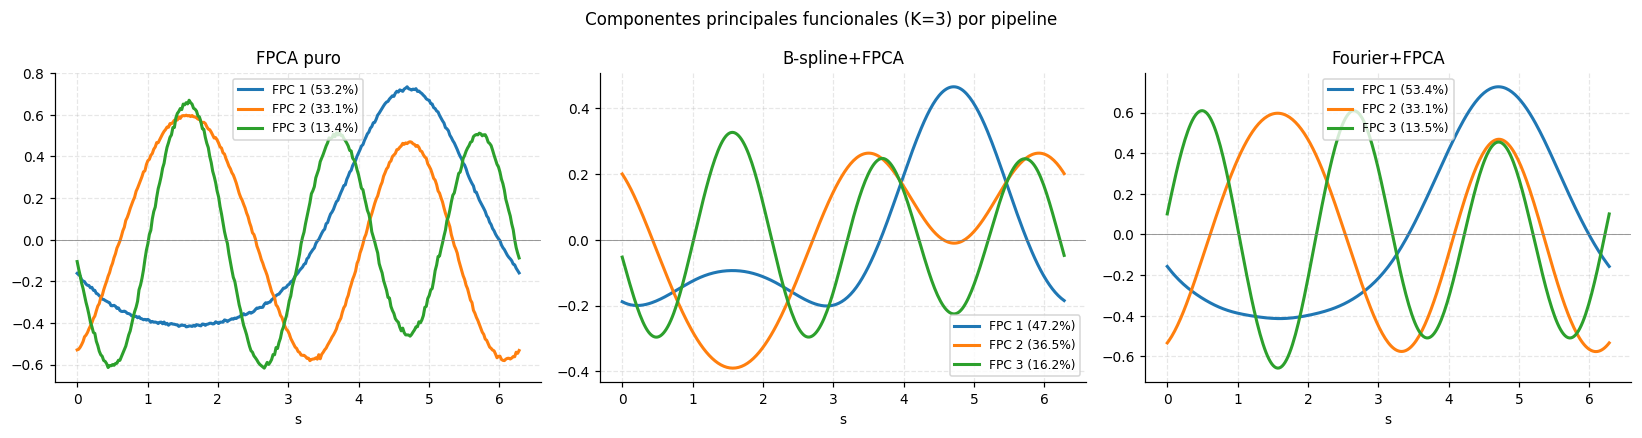

In [12]:
# ── Visualizar las FPCs de cada pipeline ─────────────────────────────────
if SKFDA_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (label, res) in zip(axes, fpca_results.items()):
        comps = res["r"].fpca_components(grid)   # (K_fpca, G)
        for k in range(comps.shape[0]):
            ax.plot(grid, comps[k], lw=2,
                    label=f"FPC {k+1} ({res['evr'][k]*100:.1f}%)")
        ax.axhline(0, color="gray", lw=0.5)
        ax.set_title(label)
        ax.set_xlabel("s")
        ax.legend(fontsize=8)

    fig.suptitle("Componentes principales funcionales (K=3) por pipeline", fontsize=11)
    plt.tight_layout()
    plt.show()

In [13]:
# ── Test: scores de los 3 pipelines son comparables (módulo signo) ───────
if SKFDA_AVAILABLE:
    th_puro = fpca_results["FPCA puro"]["THETA"]
    th_bsp  = fpca_results["B-spline+FPCA"]["THETA"]
    th_for  = fpca_results["Fourier+FPCA"]["THETA"]

    # Correlación entre los scores (las componentes pueden cambiar de signo)
    print("Correlación |ρ| entre primeros scores FPC1 de los pipelines:")
    rho_pb = abs(np.corrcoef(th_puro[:, 0], th_bsp[:, 0])[0, 1])
    rho_pf = abs(np.corrcoef(th_puro[:, 0], th_for[:, 0])[0, 1])
    rho_bf = abs(np.corrcoef(th_bsp[:, 0],  th_for[:, 0])[0, 1])
    print(f"  FPCA puro  ↔ B-spline+FPCA : {rho_pb:.4f}")
    print(f"  FPCA puro  ↔ Fourier+FPCA  : {rho_pf:.4f}")
    print(f"  B-spline+FPCA ↔ Fourier+FPCA: {rho_bf:.4f}")
    print("  (esperado: ≈1.0 — todos capturan el mismo modo latente dominante)")

Correlación |ρ| entre primeros scores FPC1 de los pipelines:
  FPCA puro  ↔ B-spline+FPCA : 0.8995
  FPCA puro  ↔ Fourier+FPCA  : 1.0000
  B-spline+FPCA ↔ Fourier+FPCA: 0.8994
  (esperado: ≈1.0 — todos capturan el mismo modo latente dominante)


## 7. Centrado: efecto sobre coeficientes y reconstrucción

El flag `center` resta la media funcional antes de proyectar. La reconstrucción suma la media de vuelta automáticamente, así que el `RMSE` debe ser **invariante al centrado**.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# Verifica que center=True afecta los COEFICIENTES (más concentrados)
# pero NO el RMSE de reconstrucción (la media se vuelve a sumar).
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    print(f"{'método':<14} {'center':>7} {'mean(|THETA|)':>15} {'RMSE L²':>10}")
    print("-" * 50)
    for method in ["bspline", "bspline+fpca"]:
        kwargs = dict(n_basis=15)
        if "fpca" in method:
            kwargs["n_basis_fpca"] = 3
        for center in [False, True]:
            r = FunctionalRepresentation(method=method, center=center, **kwargs)
            TH = r.fit_transform(Y, grid)
            err = r.reconstruction_error(Y, grid)
            print(f"{method:<14} {str(center):>7} {np.abs(TH).mean():>15.5f} "
                  f"{err['rmse_l2_mean']:>10.5f}")
    print("\n→ |THETA| medio cambia (centrado afecta escala);")
    print("  RMSE L² no cambia (la reconstrucción suma la media de vuelta).")

método          center   mean(|THETA|)    RMSE L²
--------------------------------------------------
bspline          False         0.79249    0.12280
bspline           True         0.78602    0.12206
bspline+fpca     False         1.76905    0.12525
bspline+fpca      True         1.76905    0.12452

→ |THETA| medio cambia (centrado afecta escala);
  RMSE L² no cambia (la reconstrucción suma la media de vuelta).


## 8. `from_coefficients` — instancias frozen

Para usuarios que ya tienen coeficientes calculados externamente (p. ej. desde R/fda).
Una instancia frozen:
- Tiene `K_` y `is_frozen_=True`.
- **No** soporta `transform`, `reconstruct`, `plot_basis`, `report`.
- Los coeficientes se pasan directamente al modelo PSBP.

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# Validación de from_coefficients y restricciones de instancias frozen.
# ═══════════════════════════════════════════════════════════════════════════
THETA_external = RNG.standard_normal((30, 5))
fr_frozen = FunctionalRepresentation.from_coefficients(THETA_external)

print(f"Instancia frozen creada: {fr_frozen}")
print(f"  is_frozen_  : {fr_frozen.is_frozen_}")
print(f"  is_fitted_  : {fr_frozen.is_fitted_}")
print(f"  K_          : {fr_frozen.K_}")
print()

# Operaciones que deben fallar
def expect_error(fn, exc_type, label):
    try:
        fn()
        print(f"  ✗ {label}: NO lanzó {exc_type.__name__}")
    except exc_type as e:
        msg = str(e).split(".")[0]
        print(f"  ✓ {label}: {exc_type.__name__} — {msg[:60]}...")
    except Exception as e:
        print(f"  ? {label}: excepción inesperada {type(e).__name__}")

print("Operaciones bloqueadas en instancia frozen:")
expect_error(lambda: fr_frozen.transform(Y, grid),
             RuntimeError, "transform()")
expect_error(lambda: fr_frozen.reconstruct(THETA_external),
             RuntimeError, "reconstruct()")
expect_error(lambda: fr_frozen.plot_basis(),
             RuntimeError, "plot_basis()")
expect_error(lambda: fr_frozen.report(Y, grid),
             RuntimeError, "report()")

Instancia frozen creada: FunctionalRepresentation(method='bspline', n_basis=20, frozen(K=5))
  is_frozen_  : True
  is_fitted_  : True
  K_          : 5

Operaciones bloqueadas en instancia frozen:
  ✓ transform(): RuntimeError — Instancia frozen (creada vía from_coefficients)...
  ✓ reconstruct(): RuntimeError — reconstruct() no disponible para instancias frozen...
  ✓ plot_basis(): RuntimeError — plot_basis() no disponible para frozen...
  ✓ report(): RuntimeError — report() no disponible para frozen...


## 9. Comparación global: método × K → RMSE L²

Curva de error de reconstrucción en función de la dimensión final K, para los 5 métodos.
Permite visualizar la tasa de convergencia y elegir K adecuado.

C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\functions_models\functions_repre_functional.py:481: UserWarning: FourierBasis requiere n_basis impar. Ajustado a 9.
  warnings.warn(
C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\functions_models\functions_repre_functional.py:481: UserWarning: FourierBasis requiere n_basis impar. Ajustado a 11.
  warnings.warn(
C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\functions_models\functions_repre_functional.py:481: UserWarning: FourierBasis requiere n_basis impar. Ajustado a 13.
  warnings.warn(
C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\functions_models\functions_repre_functional.py:481: UserWarning: FourierBasis requiere n_basis impar. Ajustado a 21.
  warnings.warn(
C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\functions_models\functions_repre_functional.py:481: UserWarning: FourierBasis requiere n_basis impar. Ajustado a 21.
  warnings.warn(


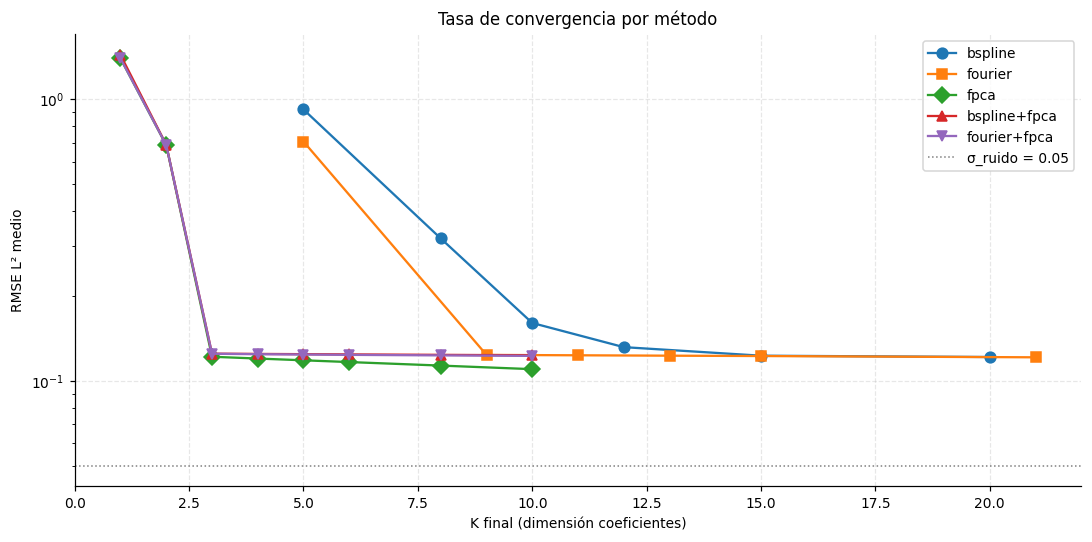

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# Curva K → RMSE L² para los 5 métodos.
# Para los encadenados, n_basis (suavizado) se fija en 20 y n_basis_fpca varía.
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    K_values_base = [5, 8, 10, 12, 15, 20]      # para métodos directos
    K_values_fpca = [1, 2, 3, 4, 5, 6, 8, 10]   # para FPCA y encadenados

    results = {}

    for method in ["bspline", "fourier"]:
        results[method] = []
        for k in K_values_base:
            r = FunctionalRepresentation(method=method, n_basis=k)
            try:
                r.fit(Y, grid)
                err = r.reconstruction_error(Y, grid)
                results[method].append((r.K_, err["rmse_l2_mean"]))
            except Exception as e:
                print(f"  {method} K={k}: {e}")

    for method in ["fpca", "bspline+fpca", "fourier+fpca"]:
        results[method] = []
        for k in K_values_fpca:
            kwargs = dict(method=method, n_basis_fpca=k)
            if "+" in method:
                kwargs["n_basis"] = max(k + 1, 20)
            r = FunctionalRepresentation(**kwargs)
            try:
                r.fit(Y, grid)
                err = r.reconstruction_error(Y, grid)
                results[method].append((r.K_, err["rmse_l2_mean"]))
            except Exception as e:
                print(f"  {method} K={k}: {e}")

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    markers = {"bspline": "o", "fourier": "s", "fpca": "D",
               "bspline+fpca": "^", "fourier+fpca": "v"}
    for method, pairs in results.items():
        ks   = [p[0] for p in pairs]
        rmse = [p[1] for p in pairs]
        ax.plot(ks, rmse, marker=markers[method], lw=1.5, ms=7, label=method)
    ax.axhline(noise_std, color="gray", lw=1, ls=":", label=f"σ_ruido = {noise_std}")
    ax.set_xlabel("K final (dimensión coeficientes)")
    ax.set_ylabel("RMSE L² medio")
    ax.set_yscale("log")
    ax.set_title("Tasa de convergencia por método")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

## 10. `report()` — mini-reporte de diagnóstico

El método `report` genera una figura 2×2 con (a) base/FPCs, (b) media funcional, (c) curvas originales vs reconstruidas, (d) varianza explicada (FPCA) o heatmap de coeficientes (base directa).

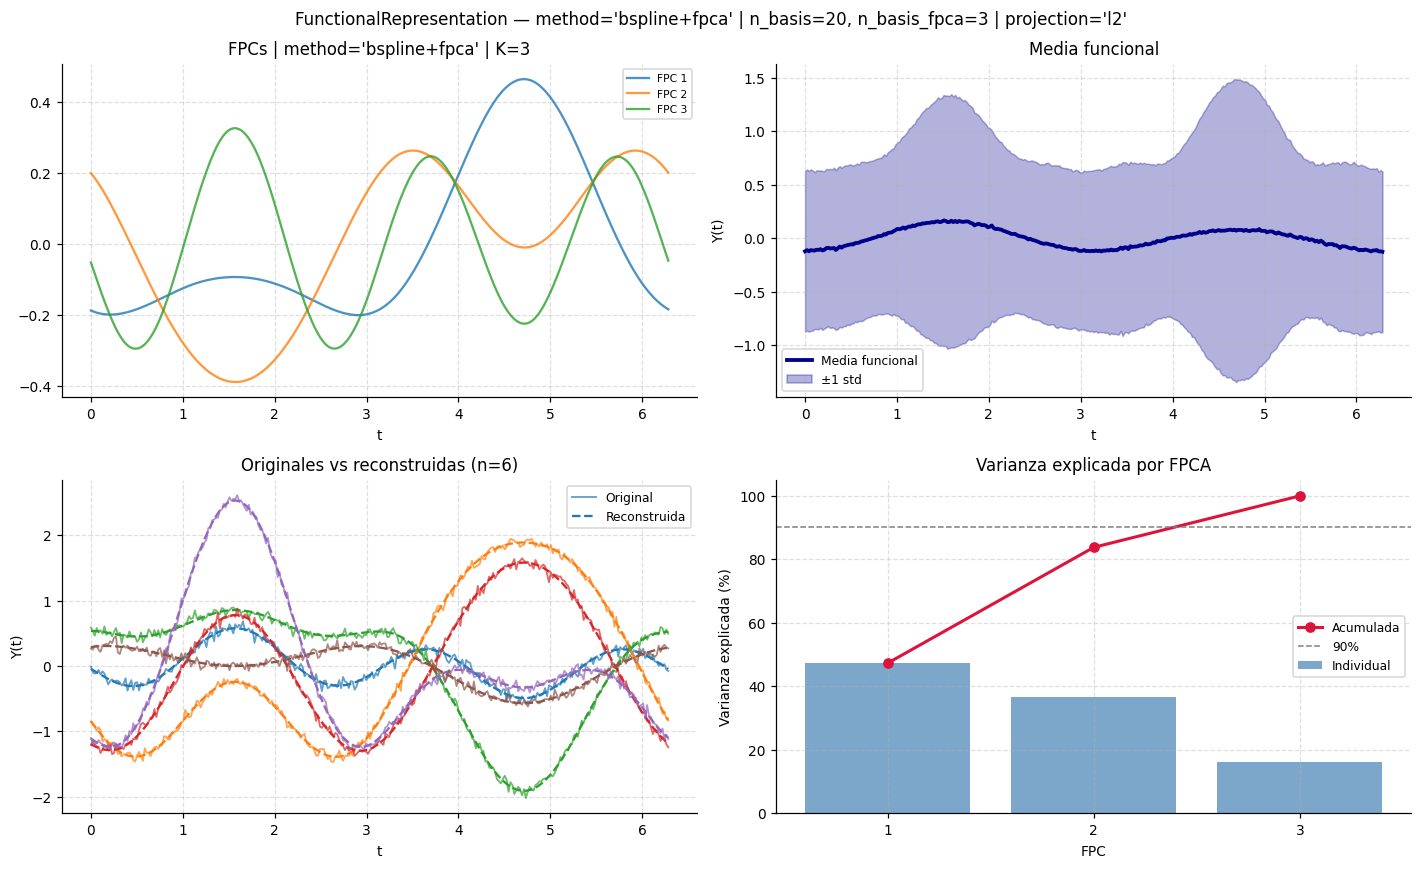

Métricas devueltas por report():
  rmse_l2_mean      : 0.12488
  rmse_l2_std       : 0.00470
  rmse_pw_mean      : 0.04982
  rmse_pw_std       : 0.00187
  rel_l2_mean       : 0.07421
  rel_l2_std        : 0.04121


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# report() para B-spline+FPCA — el caso flagship.
# ═══════════════════════════════════════════════════════════════════════════
if SKFDA_AVAILABLE:
    r_report = FunctionalRepresentation(method="bspline+fpca",
                                          n_basis=20, n_basis_fpca=3,
                                          projection="l2")
    r_report.fit(Y, grid)
    result = r_report.report(Y, grid, save_path=None, n_curves_show=6)
    plt.show()

    print("Métricas devueltas por report():")
    for k, v in result["reconstruction_error"].items():
        print(f"  {k:<18}: {v:.5f}")

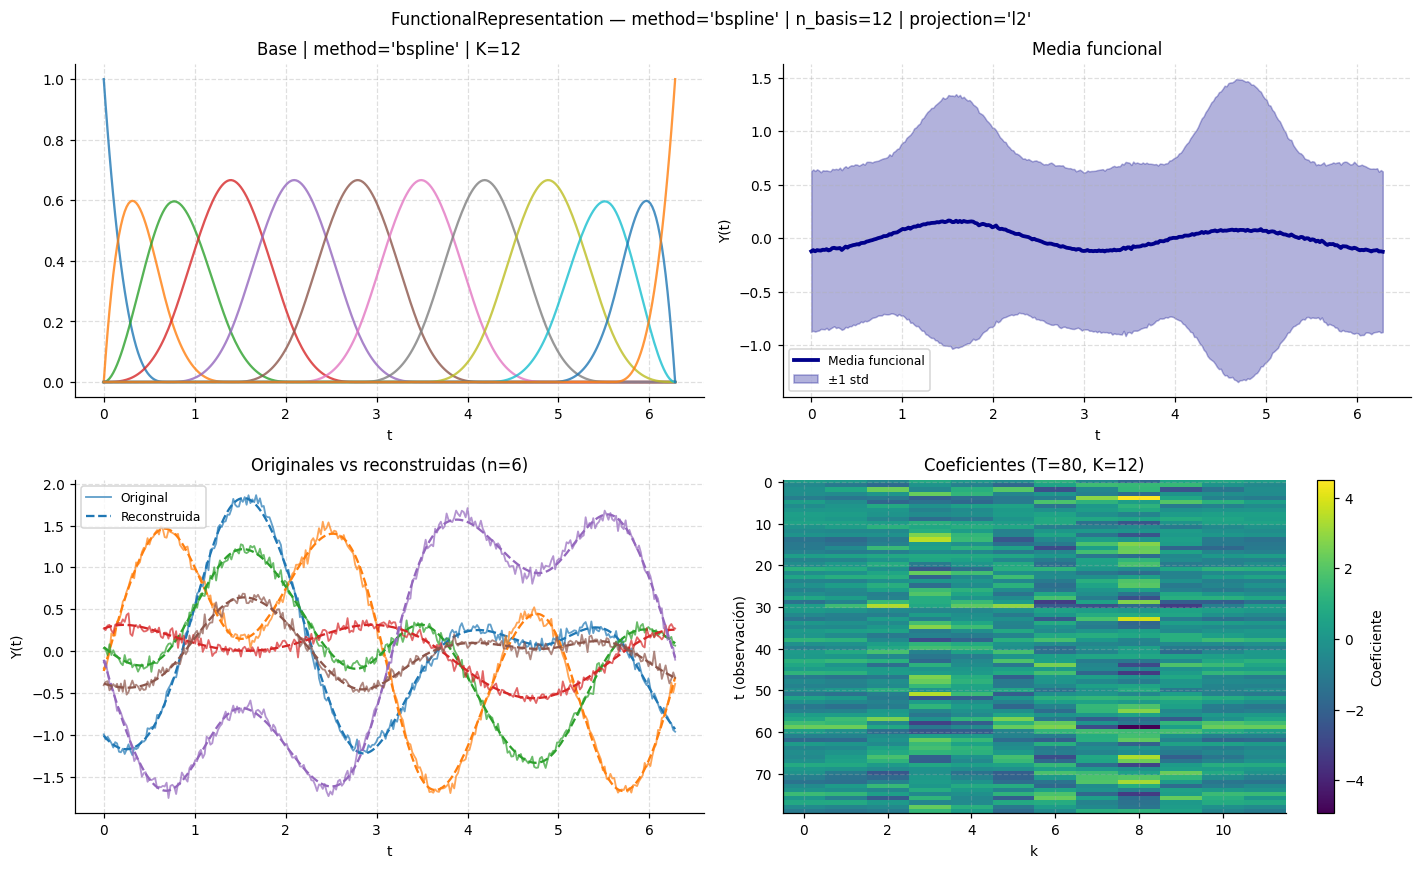

In [18]:
# ── report() para B-spline puro (panel D ahora es heatmap) ────────────────
if SKFDA_AVAILABLE:
    r_direct = FunctionalRepresentation(method="bspline", n_basis=12,
                                          projection="l2")
    r_direct.fit(Y, grid)
    r_direct.report(Y, grid, save_path=None, n_curves_show=6)
    plt.show()

## 11. Manejo de errores

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# Verificación de validaciones del constructor y métodos.
# ═══════════════════════════════════════════════════════════════════════════
def check_error(fn, exc, label):
    try:
        fn()
        print(f"  ✗ {label}: NO lanzó {exc.__name__}")
    except exc:
        print(f"  ✓ {label}: {exc.__name__}")
    except Exception as e:
        print(f"  ? {label}: inesperado {type(e).__name__}: {e}")

print("Validaciones del constructor:")
check_error(lambda: FunctionalRepresentation(method="invalid"),
            ValueError, "method inválido")
check_error(lambda: FunctionalRepresentation(projection="invalid"),
            ValueError, "projection inválido")
check_error(lambda: FunctionalRepresentation(quadrature="invalid"),
            ValueError, "quadrature inválido")
check_error(lambda: FunctionalRepresentation(n_basis=0),
            ValueError, "n_basis < 1")
check_error(lambda: FunctionalRepresentation(method="fpca", n_basis_fpca=0),
            ValueError, "n_basis_fpca < 1 con fpca")

print("\nValidaciones de fit/transform:")
check_error(lambda: FunctionalRepresentation().transform(Y, grid),
            RuntimeError, "transform() sin fit")
check_error(lambda: FunctionalRepresentation().reconstruct(np.zeros((10, 3))),
            RuntimeError, "reconstruct() sin fit")

if SKFDA_AVAILABLE:
    check_error(lambda: FunctionalRepresentation().fit(Y[0], grid),
                ValueError, "fit() con Y 1D")
    check_error(lambda: FunctionalRepresentation().fit(Y, grid[:50]),
                ValueError, "fit() con G inconsistente")
    check_error(lambda: FunctionalRepresentation().fit(Y, grid[::-1]),
                ValueError, "fit() con grid no creciente")
    check_error(
        lambda: FunctionalRepresentation(method="bspline+fpca",
                                          n_basis=5, n_basis_fpca=10).fit(Y, grid),
        ValueError, "n_basis_fpca > n_basis en encadenado")

Validaciones del constructor:
  ✓ method inválido: ValueError
  ✓ projection inválido: ValueError
  ✓ quadrature inválido: ValueError
  ✓ n_basis < 1: ValueError
  ✓ n_basis_fpca < 1 con fpca: ValueError

Validaciones de fit/transform:
  ✓ transform() sin fit: RuntimeError
  ✓ reconstruct() sin fit: RuntimeError
  ✓ fit() con Y 1D: ValueError
  ✓ fit() con G inconsistente: ValueError
  ✓ fit() con grid no creciente: ValueError
  ✓ n_basis_fpca > n_basis en encadenado: ValueError


## 12. Resumen final

In [20]:
sep = "=" * 65
print(sep)
print("  RESUMEN — FunctionalRepresentation")
print(sep)

print("\n  API básica")
print("    ✓ 5 métodos: bspline, fourier, fpca, bspline+fpca, fourier+fpca")
print("    ✓ fit / transform / fit_transform / reconstruct")
print("    ✓ reconstruction_error con 6 indicadores (L² y pointwise)")
print("    ✓ summary() y get_config()")

print("\n  Proyección y cuadratura")
print("    ✓ projection='l2' (default) y 'discrete'")
print("    ✓ L² ≈ discreta en grilla equiespaciada")
print("    ✓ trapezoid (default) y simpson; fallback con warning en G par")

print("\n  Encadenado base → FPCA")
print("    ✓ bspline+fpca y fourier+fpca con n_basis_fpca < n_basis")
print("    ✓ Var. explicada acumulada > 99% con K=3 sobre 3 modos latentes")
print("    ✓ Scores correlacionados ~1 entre FPCA puro y encadenados")

print("\n  Centrado")
print("    ✓ center=True afecta escala de THETA pero no RMSE de reconstrucción")

print("\n  from_coefficients (frozen)")
print("    ✓ Crea instancia con K_ y is_frozen_=True")
print("    ✓ Bloquea correctamente transform, reconstruct, plot_*, report")

print("\n  Reporte y plots")
print("    ✓ report() genera figura 2x2 con métricas")
print("    ✓ plot_basis, plot_curves, plot_mean, plot_coefficients,")
print("      plot_fpca_variance disponibles")

print("\n  Validaciones")
print("    ✓ Constructor rechaza method/projection/quadrature inválidos")
print("    ✓ fit rechaza Y 1D, G inconsistente, grid no creciente")
print("    ✓ Encadenado rechaza n_basis_fpca > n_basis")

print("\n  PENDIENTE")
print("    □ Validación de FunctionalStandarizer (clase futura)")
print("    □ Pipeline integrado con PSBP_FD_v1 sobre coeficientes funcionales")

print("\n" + sep)

  RESUMEN — FunctionalRepresentation

  API básica
    ✓ 5 métodos: bspline, fourier, fpca, bspline+fpca, fourier+fpca
    ✓ fit / transform / fit_transform / reconstruct
    ✓ reconstruction_error con 6 indicadores (L² y pointwise)
    ✓ summary() y get_config()

  Proyección y cuadratura
    ✓ projection='l2' (default) y 'discrete'
    ✓ L² ≈ discreta en grilla equiespaciada
    ✓ trapezoid (default) y simpson; fallback con warning en G par

  Encadenado base → FPCA
    ✓ bspline+fpca y fourier+fpca con n_basis_fpca < n_basis
    ✓ Var. explicada acumulada > 99% con K=3 sobre 3 modos latentes
    ✓ Scores correlacionados ~1 entre FPCA puro y encadenados

  Centrado
    ✓ center=True afecta escala de THETA pero no RMSE de reconstrucción

  from_coefficients (frozen)
    ✓ Crea instancia con K_ y is_frozen_=True
    ✓ Bloquea correctamente transform, reconstruct, plot_*, report

  Reporte y plots
    ✓ report() genera figura 2x2 con métricas
    ✓ plot_basis, plot_curves, plot_mean, pl